# Continuous wavelet transform (CWT):

A CWT allows us to analyse a signal into different frequencies at different time resolutions by using a window function of a wavepacket (called a wavelet here). It can be shifted, shrunken (capture details of the signal) and stretched (capture overall trend of the signal).

Wavelet transforms refer to a set of methods to carry out spectral analysis in the time domain, involving a multi-resolution analysis.

$$
\begin{equation}
X(\tau, s) = \frac{1}{\sqrt{|s|}} \int_{-\infty}^{\infty} x(t) \, \overline{\psi\left( \frac{t - \tau}{s} \right)} \, dt
\end{equation}
$$


# Discrete wavelet transform (DWT):

A CWT calculates spectral coefficients at all scales, while the DWT takes $s$ and $\tau$ as discrete values, which reduces the amount of data to be computed. $s$ and $\tau$ are usually powers of dyadics.

$$
\begin{equation}
X(\tau, s) = \frac{1}{\sqrt{s}} \sum_{i = 0}^{p - 1} x[t_i] \ \psi [\frac{t_i - \tau}{s}]
\end{equation}
$$
where,

$\tau = k \ 2^{-j}$

$s = 2^{-j}$

p: number of WT coefficients.

j: index of scaling.

k: index of WT coefficients.

A DWT results into sets of 2 types of coefficients:

## Approximation coefficients ($C_A$): 

- Wavelets with large values of $s$ (they're stretched).

- They represent the low-frequency parts of the signal, the overall trend.

## Detail coefficients ($C_D$):

- Wavelets with small values of $s$ (they're compressed).

- They represent the high-frequency parts of the signal, the details or sharp features.


# Multilevel decomposition of the DWT:

It's based on repeatedly decomposing a signal into a low-frequency part ($C_A$) and a high-frequency part ($C_D$). We do this for each level (tree-like structure) until there is no more elements.

## Algorithm:

- The signal is passed into **low pass** and **high pass** filters.

- The low pass portions (**approximation coefficients**) are iteratively filtered by the same process.

- The number of coefficients is reduced by half at each level.

- The high pass portions correspond to the **detail coefficients**.

- The decomposition produces sets of approximation and detail coefficients at different levels.


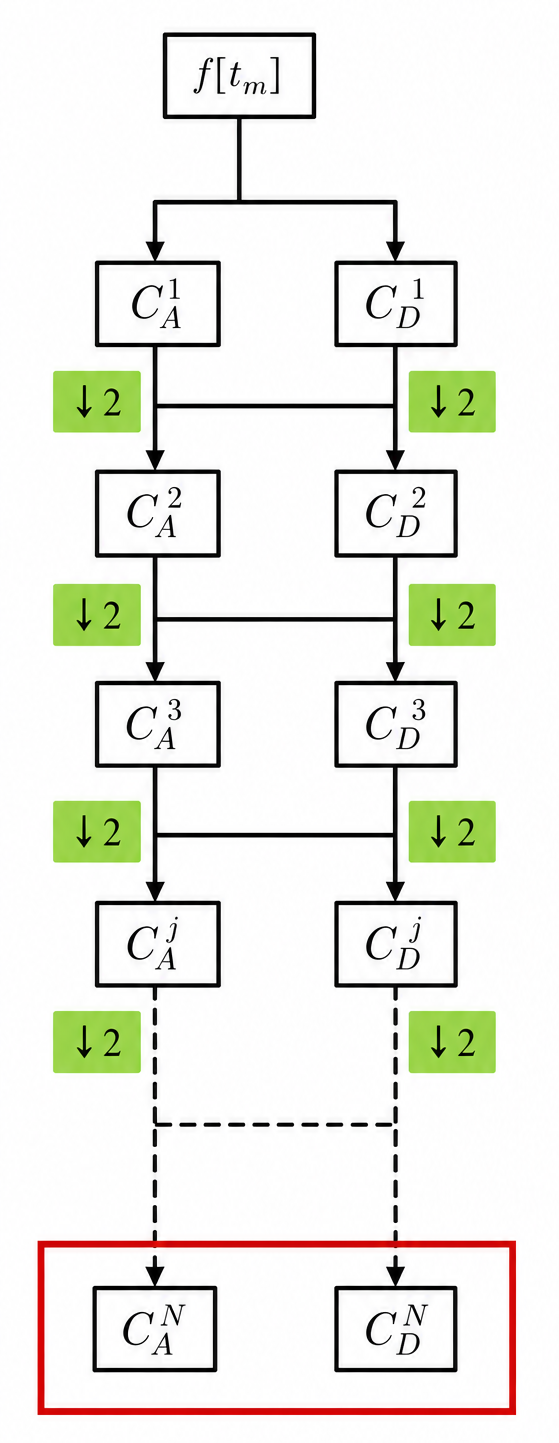


## Python libraries for DWT:

We have 2 options:

- ``pywt.dwt``

- ``pywt.wavedec``

### Example 1:

Let's carry out a DWT of this signal:

$f(n) = (2, 4, 6, 8, 9, -2, 3, -4)$ 

Then, carry out an inverse DWT to recover the signal.

In [1]:
import pywt
import matplotlib.pyplot as plt

# https://pywavelets.readthedocs.io/en/latest/

In [2]:
print("These are the possible wavelets: ", pywt.wavelist())

These are the possible wavelets:  ['bior1.1', 'bior1.3', 'bior1.5', 'bior2.2', 'bior2.4', 'bior2.6', 'bior2.8', 'bior3.1', 'bior3.3', 'bior3.5', 'bior3.7', 'bior3.9', 'bior4.4', 'bior5.5', 'bior6.8', 'cgau1', 'cgau2', 'cgau3', 'cgau4', 'cgau5', 'cgau6', 'cgau7', 'cgau8', 'cmor', 'coif1', 'coif2', 'coif3', 'coif4', 'coif5', 'coif6', 'coif7', 'coif8', 'coif9', 'coif10', 'coif11', 'coif12', 'coif13', 'coif14', 'coif15', 'coif16', 'coif17', 'db1', 'db2', 'db3', 'db4', 'db5', 'db6', 'db7', 'db8', 'db9', 'db10', 'db11', 'db12', 'db13', 'db14', 'db15', 'db16', 'db17', 'db18', 'db19', 'db20', 'db21', 'db22', 'db23', 'db24', 'db25', 'db26', 'db27', 'db28', 'db29', 'db30', 'db31', 'db32', 'db33', 'db34', 'db35', 'db36', 'db37', 'db38', 'dmey', 'fbsp', 'gaus1', 'gaus2', 'gaus3', 'gaus4', 'gaus5', 'gaus6', 'gaus7', 'gaus8', 'haar', 'mexh', 'morl', 'rbio1.1', 'rbio1.3', 'rbio1.5', 'rbio2.2', 'rbio2.4', 'rbio2.6', 'rbio2.8', 'rbio3.1', 'rbio3.3', 'rbio3.5', 'rbio3.7', 'rbio3.9', 'rbio4.4', 'rbio5.5'

In [3]:
# signal:

f = [2, 4, 6, 8, 9, -2, 3, -4]

print(f, len(f))

[2, 4, 6, 8, 9, -2, 3, -4] 8


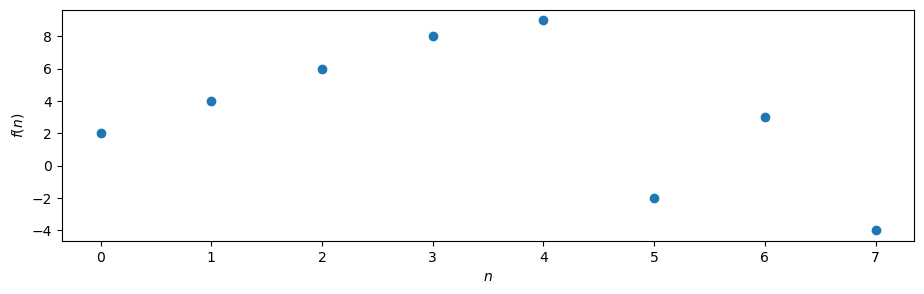

In [4]:
plt.figure(figsize=(11,3))

plt.plot(f, marker = "o", linestyle = " ")

plt.xlabel(r"$n$")

plt.ylabel(r"$f(n)$")

plt.show()

In [5]:
# DWT:

cA, cD = pywt.dwt(f, 'haar')

In [6]:
print(cA) # approximation coef.
print(cA.shape)

[ 4.24264069  9.89949494  4.94974747 -0.70710678]
(4,)


In [7]:
print(cD) # detail coef.
print(cD.shape)

[-1.41421356 -1.41421356  7.77817459  4.94974747]
(4,)


## Full signal reconstruction:

In [8]:
# iDWT

f_recovered = pywt.idwt(cA, cD, 'haar')

In [9]:
print(f)
print(f_recovered)

[2, 4, 6, 8, 9, -2, 3, -4]
[ 2.  4.  6.  8.  9. -2.  3. -4.]


### Signal reconstruction with approximation/detail coefficients only:

In [10]:
# iDWT
# Only CA
f_ca = pywt.idwt(cA, None, 'haar')

# Only CD
f_cd = pywt.idwt(None, cD, 'haar')

In [11]:
print(f_ca)
print(f_ca.shape)

print(f_cd)
print(f_cd.shape)

[ 3.   3.   7.   7.   3.5  3.5 -0.5 -0.5]
(8,)
[-1.   1.  -1.   1.   5.5 -5.5  3.5 -3.5]
(8,)


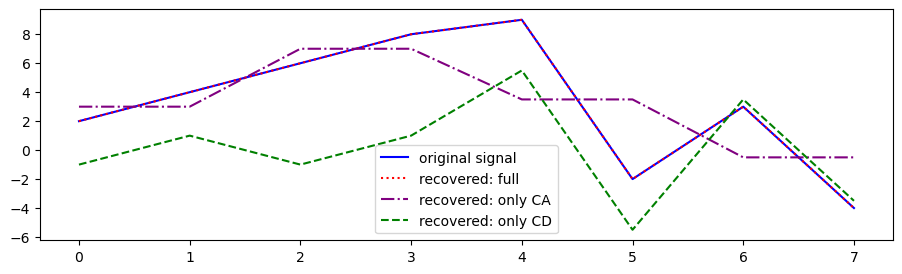

In [12]:
plt.figure(figsize=(11,3))

plt.plot(f, color = "blue", label= "original signal")

plt.plot(f_recovered, color = "red", linestyle = ":", label= "recovered: full")

plt.plot(f_ca, color = "purple", linestyle = "-.", label= "recovered: only CA")

plt.plot(f_cd, color = "green", linestyle = "--", label= "recovered: only CD")

plt.legend()
plt.show()

### Example 2:

$$f(x)= A\sin(k\,x) + b\,n(x)$$

In [13]:
import numpy as np

In [14]:
# Pure sine function

def func(x_axis, a, k, b):
    """
    Inputs:
    a -> amplitude of the sine function
    k -> wavenumber
    b -> noise amplitude
    """
    f_sin = a*np.sin(k*x) + b*np.random.randn(len(x))
    
    return f_sin

In [15]:
# Generate x axis
x = np.linspace(0., 4*np.pi, 1000)

# Fix properties
a = 1.
k = 3./(np.pi)
b = 0.05

# Evaluate our function
noisy_sine = func(x, a, k, b)

print(x.shape, noisy_sine.shape)

(1000,) (1000,)


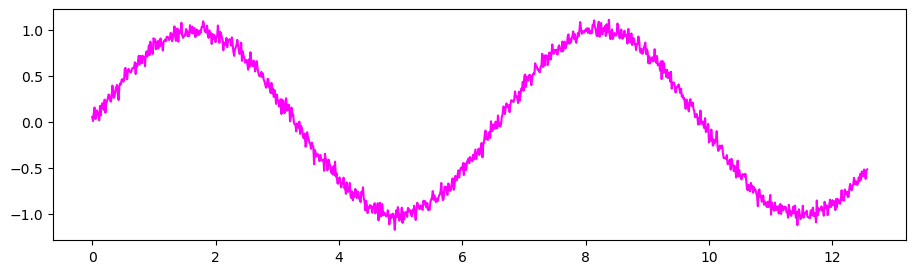

In [16]:
plt.figure(figsize=(11, 3))

plt.plot(x, noisy_sine, color = "magenta")

plt.show()

### Wavelet transforms:

In [17]:
# DWT:

cA, cD = pywt.dwt(noisy_sine, 'haar')

print(noisy_sine.shape, cA.shape, cD.shape)

(1000,) (500,) (500,)


### Reconstruct the full signal:

In [18]:
# iDWT

f_recovered = pywt.idwt(cA, cD, 'haar')

print(f_recovered.shape)

(1000,)


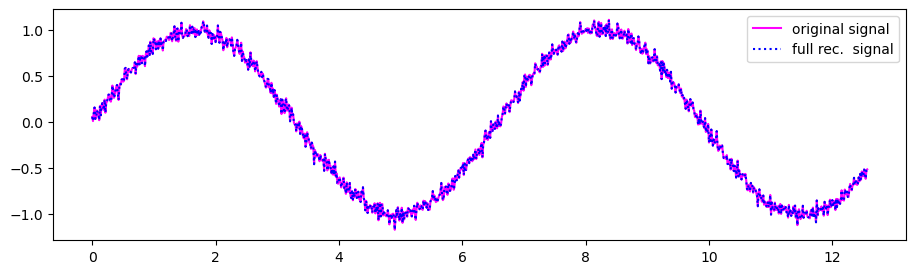

In [19]:
plt.figure(figsize=(11, 3))

plt.plot(x, noisy_sine, color = "magenta", label = "original signal")

plt.plot(x, f_recovered, linestyle = ":", color = "blue", label = "full rec.  signal")

plt.legend()

plt.show()

### Only low frequencies: Only with cA coefficients

In [20]:
# iDWT

f_ca = pywt.idwt(cA, None, 'haar')

print(x.shape, f_ca.shape)

(1000,) (1000,)


### Only high frequencies: Only with cD coefficients

In [21]:
# iDWT

f_cd = pywt.idwt(None, cD, 'haar')

print(f_cd.shape)

(1000,)


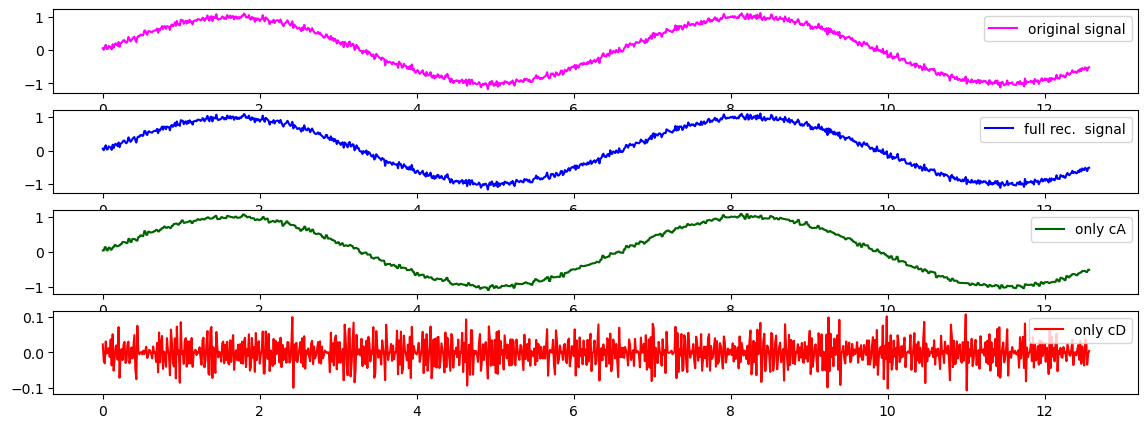

In [22]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize = (14,5))

ax1.plot(x, noisy_sine, color = "magenta", label = "original signal")
ax1.legend()

ax2.plot(x, f_recovered, linestyle = "-", color = "blue", label = "full rec.  signal")
ax2.legend()

ax3.plot(x, f_ca, linestyle = "-", color = "darkgreen", label = "only cA")
ax3.legend()

ax4.plot(x, f_cd, linestyle = "-", color = "red", label = "only cD")
ax4.legend()
plt.show()

### Second level of decomposition

In [23]:
# DWT:

cA2, cD2 = pywt.dwt(f_ca, 'haar')

print(noisy_sine.shape, f_ca.shape)

(1000,) (1000,)


In [24]:
# iDWT

f_ca2 = pywt.idwt(cA2, None, 'haar')

f_cd2 = pywt.idwt(None, cD2, 'haar')

print(x.shape, f_ca2.shape, f_cd2.shape)

(1000,) (1000,) (1000,)


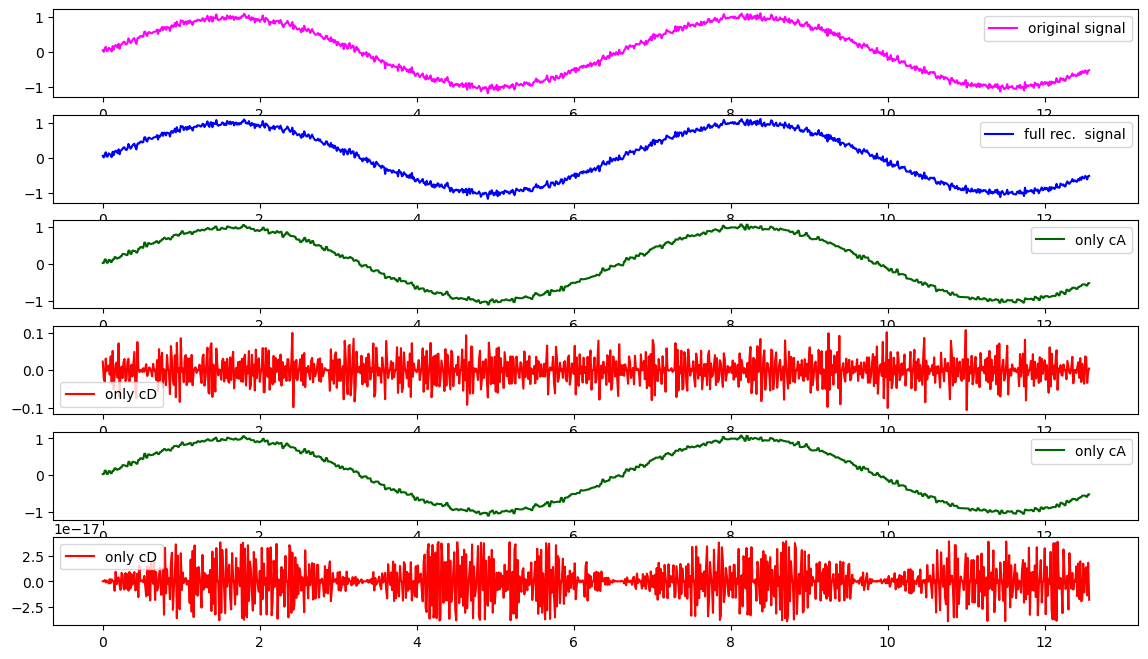

In [25]:
fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(6, 1, figsize = (14,8))

ax1.plot(x, noisy_sine, color = "magenta", label = "original signal")
ax1.legend()

ax2.plot(x, f_recovered, linestyle = "-", color = "blue", label = "full rec.  signal")
ax2.legend()

ax3.plot(x, f_ca, linestyle = "-", color = "darkgreen", label = "only cA")
ax3.legend()

ax4.plot(x, f_cd, linestyle = "-", color = "red", label = "only cD")
ax4.legend()

ax5.plot(x, f_ca2, linestyle = "-", color = "darkgreen", label = "only cA")
ax5.legend()

ax6.plot(x, f_cd2, linestyle = "-", color = "red", label = "only cD")
ax6.legend()

plt.show()

## Wavelet transform analysis using ``pywt.wavedec``:

- `pywt.wavedec`:
  Performs a multilevel 1D wavelet decomposition of a signal.  
  It returns the approximation and detail coefficients at different scales.


``python
coeffs = pywt.wavedec(x, 'wavelet', mode ='sym', level = n)
``

- `pywt.waverec`:
  Reconstructs the original signal from the wavelet coefficients obtained with `wavedec`.

``python
y = pywt.waverec(coeffs, 'wavelet', mode ='sym')
``

### Revisit the first example

In [26]:
print(f)

[2, 4, 6, 8, 9, -2, 3, -4]


### DWT decomposition:

In [27]:
coeffs = pywt.wavedec(f, 'db1', level = 2, mode = 'periodic')

cA2, cD2, cD1 = coeffs

print(cA2)
print(cD2)
print(cD1)

[10.  3.]
[-4.  4.]
[-1.41421356 -1.41421356  7.77817459  4.94974747]


### DWT reconstruction:

In [28]:
f_recovered2 = pywt.waverec(coeffs, 'db1', mode = 'periodic')

In [29]:
print(f)
print(f_recovered2)

[2, 4, 6, 8, 9, -2, 3, -4]
[ 2.  4.  6.  8.  9. -2.  3. -4.]


### Signal reconstruction ignoring the last level

In [30]:
coeffs[-1] = np.zeros_like(coeffs[-1])

f_c1 = pywt.waverec(coeffs, 'db1', mode = 'periodic')

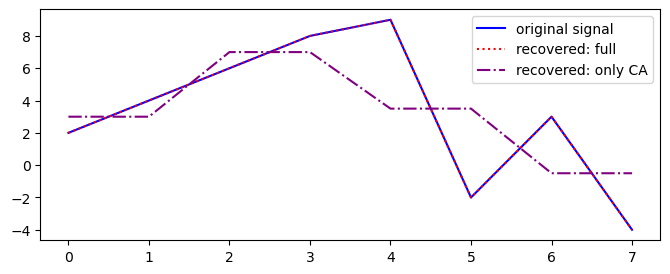

In [31]:
plt.figure(figsize=(8,3))

plt.plot(f, color = "blue", label= "original signal")

plt.plot(f_recovered2, color = "red", linestyle = ":", label= "recovered: full")

plt.plot(f_c1, color = "purple", linestyle = "-.", label= "recovered: only CA")

#plt.plot(f_cd, color = "green", linestyle = "--", label= "recovered: only CD")

plt.legend()
plt.show()

### Revisit the second example

#### DWT:

In [32]:
coeffs = pywt.wavedec(noisy_sine, 'db1', level = 2, mode = 'periodic')

cA2, cD2, cD1 = coeffs

print(cA2.shape)
print(cD2.shape)
print(cD1.shape)

(250,)
(250,)
(500,)


In [37]:
print(len(coeffs))

print(coeffs[-2])

3
[-9.42143405e-02 -7.82836108e-02 -6.76303420e-02  3.79051409e-02
 -4.13678453e-02  1.00449072e-02 -1.20881479e-01 -8.92143676e-02
  3.93887597e-02 -4.93752419e-02 -1.40168055e-01 -8.98133916e-02
 -7.91581403e-03 -3.54031558e-02 -5.29453305e-02 -4.25970291e-02
 -2.55095013e-02 -6.84008529e-02 -8.20001423e-03 -5.38974489e-02
  7.01676987e-02 -1.57025172e-02  5.92753434e-02 -8.62884814e-03
  1.99535868e-02  1.49751795e-02 -2.96759655e-02  5.70498058e-04
 -3.93952298e-02 -6.52781343e-03  2.10560004e-02 -6.61633663e-02
  1.43368499e-02 -2.84728612e-02 -4.52048454e-03 -6.19386848e-02
  4.20912627e-02  4.14237289e-02  5.11959220e-02  2.38063280e-02
 -6.28747229e-02 -2.25112978e-02 -2.74286550e-02  3.07344480e-02
  3.52650140e-02  1.37819901e-01 -6.09452227e-02  4.41559838e-02
  1.97005737e-02  5.84880756e-03 -4.30524571e-02  1.00304259e-01
  8.18236436e-02  1.04968616e-01 -1.31456425e-02  6.80480118e-02
 -8.89274210e-02  3.89162062e-03  2.73621909e-02 -2.41511135e-02
 -4.09318494e-02 -1.304

### Reconstruct signal in full:

In [38]:
noisy_sine_rec = pywt.waverec(coeffs, 'db1', mode = 'periodic')

In [39]:
coeffs[-2] = np.zeros_like(coeffs[-2])

coeffs[-1] = np.zeros_like(coeffs[-1])

noisy_sine_c2 = pywt.waverec(coeffs, 'db1', mode = 'periodic')

In [40]:
print(len(coeffs))

print(coeffs[-2])

3
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


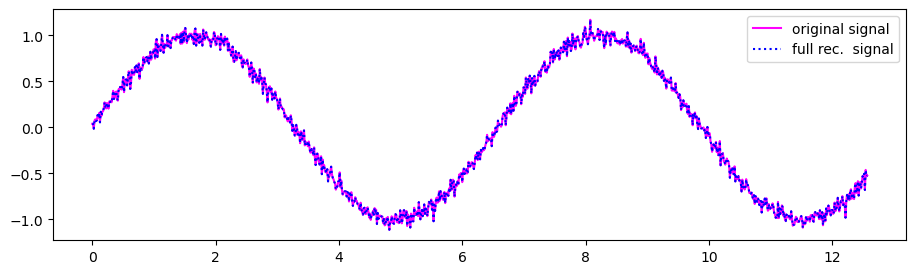

In [39]:
plt.figure(figsize=(11, 3))

plt.plot(x, noisy_sine, color = "magenta", label = "original signal")

plt.plot(x, noisy_sine_rec, linestyle = ":", color = "blue", label = "full rec.  signal")


plt.legend()

plt.show()

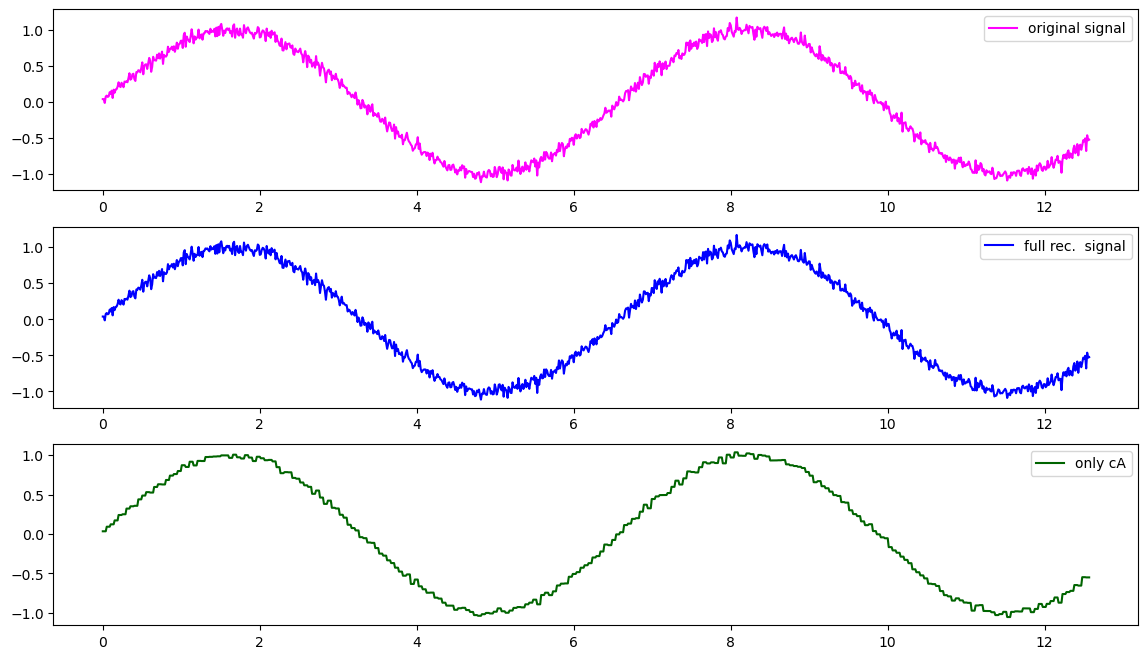

In [40]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (14,8))

ax1.plot(x, noisy_sine, color = "magenta", label = "original signal")
ax1.legend()

ax2.plot(x, noisy_sine_rec, linestyle = "-", color = "blue", label = "full rec.  signal")
ax2.legend()

ax3.plot(x, noisy_sine_c2, linestyle = "-", color = "darkgreen", label = "only cA")
ax3.legend()

plt.show()